In [1]:
import xarray as xr
import numpy as np

### Load & Normalization

In [24]:
ds = xr.load_dataarray('../data/SiC_100x10.nc')
# Background removal
bg_removal_window = ds.sel(wave_number=slice(2200, 2500))
bg_value = bg_removal_window.median()
ds = ds - bg_value
# Normalization to the max
ds = ds / ds.max(dim='wave_number')

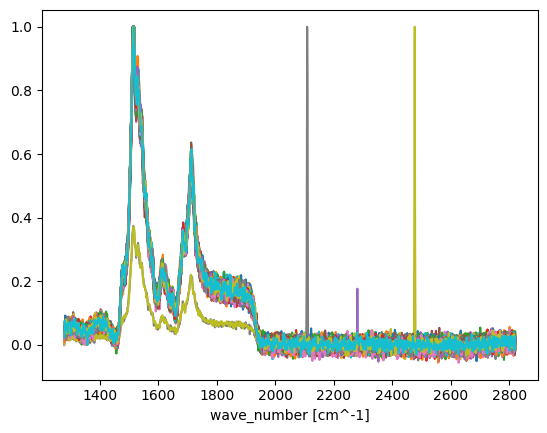

In [25]:
# Plot the first 100 spectra
ds.stack(spectra=('X', 'Y')).isel(spectra=slice(0, 100)).plot.line(x='wave_number', add_legend=False);

### Find outliers

In [32]:
median_counts = ds.median(dim=['X', 'Y'])
sup_norm_deviations = (abs(ds - median_counts)).max(dim='wave_number')
filtered_ds = ds.where(sup_norm_deviations < 0.15, drop=True)
filtered_ds = filtered_ds.stack(spectra=('X', 'Y')).dropna(dim='spectra')
print(f"Dropped {len(ds.X)*len(ds.Y) - len(filtered_ds.spectra)} spectra")

Dropped 20 spectra


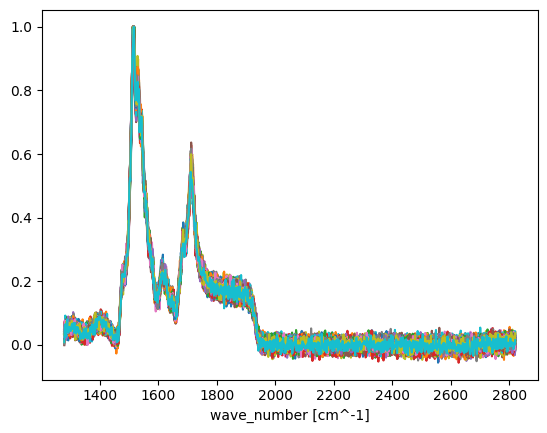

In [33]:
filtered_ds.isel(spectra=slice(0, 100)).plot.line(x='wave_number', add_legend=False);